In [4]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import skimage as ski
import xarray as xr
import sys

from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from pyS3M import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

import pyS3M.gaussoptfuncs as gaussoptfuncs
from numba import jit
from umap import UMAP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml

/tmp/ipykernel_55430/1150034777.py:31: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [5]:
mnist = fetch_openml('mnist_784', version=1, parser='auto')

In [6]:
reducer = UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(mnist.data)

/home/jsb92/Documents/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/jsb92/Documents/venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


/tmp/ipykernel_55430/1988376679.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


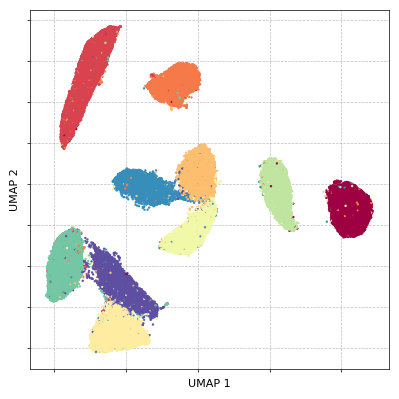

In [32]:
fig, axs = plotter.two_column_plot(width=4, height=4)


axs.grid(alpha=0.5, color='gray', ls='--', lw=0.5)
axs.scatter(embedding[:, 0], embedding[:, 1], 
            c=mnist.target.astype(int), cmap='Spectral', s=0.5, rasterized=True)
axs.set_xlabel('UMAP 1', fontsize=8)
axs.set_ylabel('UMAP 2', fontsize=8)
axs.set_yticklabels([])
axs.set_xticklabels([])
axs.set_axisbelow(True)
plt.tight_layout()
plt.savefig('/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Example_UMAP.svg', dpi=600, format='svg')
plt.show()